In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
# from matplotlib.ticker import MultipleLocator
import os

from hist_info_extractor import ExtractHistData

from coffea.util import load
cms_color = {
    "blue": "#3f90da",
    "orange": "#ffa90e",
    "red": "#bd1f01",
    "gray": "#94a4a2",
    "purple": "#832db6",
    "brown": "#a96b59",
    "dark_orange": "#e76300",
    "beige": "#b9ac70",
    "dark_gray": "#717581",
    "light_blue": "#92dadd",
    'cyan': '#17becf',
    'yellow-green': '#bcbd22',
}

In [7]:
class Plotter:
    def __init__(self, hist_info):
        self.hist_info = hist_info
        self.colors = [cms_color["red"], cms_color["orange"], cms_color["purple"],
                       cms_color["beige"], cms_color["blue"], cms_color["dark_gray"],
                       cms_color["light_blue"], cms_color["brown"], cms_color["dark_orange"],
                       cms_color["gray"], cms_color["yellow-green"], cms_color["cyan"]]

    def define_figure(self):
        # self.fig, (self.ax, self.rax) = plt.subplots(
        #     2, 1, figsize=(10, 8), 
        #     gridspec_kw={"height_ratios": [3, 1], "hspace": 0.0}, 
        #     sharex=True
        # )
        self.fig, self.ax = plt.subplots(
            1, figsize=(10, 8)
        )

    def plot_datamc(self):
        
        bottom = np.zeros(len(self.hist_info.bin_centers))
        for i, (name, values) in enumerate(self.hist_info.backgrounds.items()):
            self.ax.bar(
                self.hist_info.bin_centers, values, width=self.hist_info.bin_widths,
                bottom=bottom, alpha=0.8, label=name, color=self.colors[i],
                edgecolor='black', linewidth=0.5
            )
            bottom += values
            
        # self.ax.errorbar(
        #     self.hist_info.bin_centers, self.hist_info.data, yerr=self.hist_info.stat,
        #     fmt='o', color='black', markersize=5, capsize=0,
        #     linewidth=2, label='Data'
        # )
        
        for i, (name, values) in enumerate(self.hist_info.signals.items()):
            self.ax.step(
                self.hist_info.bins, np.append(values, values[-1])*30000, where='post',
                alpha=1, linestyle="dashed", label=name, color=self.colors[4], linewidth=4
            )
        
        # lower = self.hist_info.total_backgrounds - self.hist_info.syst
        # upper = self.hist_info.total_backgrounds + self.hist_info.syst
        # self.ax.fill_between(
        #     self.hist_info.bins,
        #     np.append(lower, lower[-1]),
        #     np.append(upper, upper[-1]),
        #     step='post', facecolor="None", alpha=0.9, hatch='////',
        #     label="stat unc.", edgecolor='black', linewidth=0
        # )
        
        self.ax.minorticks_on()
        self.ax.tick_params(axis='both', which='major', labelsize=14, width=2, length=8)
        self.ax.tick_params(axis='both', which='minor', labelsize=12, width=1.5, length=5)
        
        # for label in ax.get_xticklabels() + ax.get_yticklabels():
        #     label.set_fontweight('bold')
        
        for spine in self.ax.spines.values():
            spine.set_linewidth(2)
            
        self.ax.set_ylabel('Events', fontsize=20)
        self.ax.set_xlabel(self.hist_info.ax_label, fontsize=20)
        self.ax.set_xlim(self.hist_info.bins[0], self.hist_info.bins[-1])
        self.ax.legend(fontsize=12, loc='best', frameon=True,
                   framealpha=1.0,
                   edgecolor='black',
                   fancybox=False)
        self.ax.grid(True, alpha=0.3)
        # self.ax.set_yscale('log')
        # self.ax.set_title(f'Normalized differential cross section/{self.x_axis_name}', fontsize=16)
    
    def plot_ratio(self):
        ratio = self.hist_info.data / self.hist_info.total_backgrounds
        ratio_err = self.hist_info.stat / self.hist_info.total_backgrounds

        # Plot ratio
        self.rax.errorbar(self.hist_info.bin_centers, ratio, yerr=ratio_err, 
                          fmt='o', color='black', markersize=5, linewidth=1.5,
                          capsize=0, capthick=1.5, label='Data/MC')

        self.rax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5)

        syst_unc_ratio = self.hist_info.syst / self.hist_info.total_backgrounds
        lower = 1 - syst_unc_ratio
        upper = 1 + syst_unc_ratio
        self.rax.fill_between(self.hist_info.bins, np.append(lower, lower[-1]), np.append(upper, upper[-1]),
                 step='post', facecolor="None", alpha=0.9, hatch='////',
                 label='Syst. Unc.', edgecolor='black', linewidth=0)

        # Set labels and limits
        self.rax.set_xlabel(self.hist_info.ax_label, fontsize=15)
        self.rax.set_ylabel('Data/MC')
        self.rax.set_ylim(0.5, 2)
        self.rax.set_xlim(self.hist_info.bins[0], self.hist_info.bins[-1])
        self.rax.grid(True, alpha=0.3)
        self.rax.set_xlim(self.ax.get_xlim())

        # Add bin edges as x-ticks
        # ax_bottom.set_xticks(bins)
    
    def plot_histogram(self, normalized=False):
        self.define_figure()
        self.plot_datamc()
        # self.plot_ratio()

        os.makedirs(f"plots/", exist_ok=True)
        if normalized:
            plt.savefig(f"plots/{self.hist_info.var_name}_normalized.png", dpi=300, bbox_inches="tight")
        else:
            plt.savefig(f"plots/{self.hist_info.var_name}", dpi=300, bbox_inches="tight")
        plt.show()
        # plt.savefig(f"plots/{name}.pdf", bbox_inches="tight")
        plt.close()

    

In [8]:
mc_backgrounds = {
    "ttt": ["tttJets"],
    "HW": ["HW"],
    "VV+VVV": ["WZ", "WW", "ZZ", "WWW"],
    "tWZ": ["tWZ"],
    r"ttV+tVJets":["ttZ", "ttW", "tZJets"],
    "tttt": ["tttt"],
    "ttH+tHJets": ["ttH", "tHJets"],
    "VJets": ["WJets", "ZJets"],
    "tt": ["tt"],
}
mc_backgrounds_normalized = {
    "ttt": ["tttJets"],
    "tt": ["tt"],
    "tttt": ["tttt"],
    r"ttV+tVJets":["ttZ", "ttW", "tZJets"],
    "VV+VVV": ["WZ", "WW", "ZZ", "WWW"],
    "tWZ": ["tWZ"],
    "ttH+tHJets": ["ttH", "tHJets"],
    "HW": ["HW"],
    "VJets": ["WJets", "ZJets"],
}
signals = [
    # "Signal_500",
    # "Signal_600",
    # "Signal_700",
    # "Signal_800",
    # "Signal_900",
    "Signal_500",
    # "Signal_1100",
    # "Signal_1200",
    # "Signal_1300",
    # "Signal_1400",
    # "Signal_1500",
    # "Signal_2000",
]

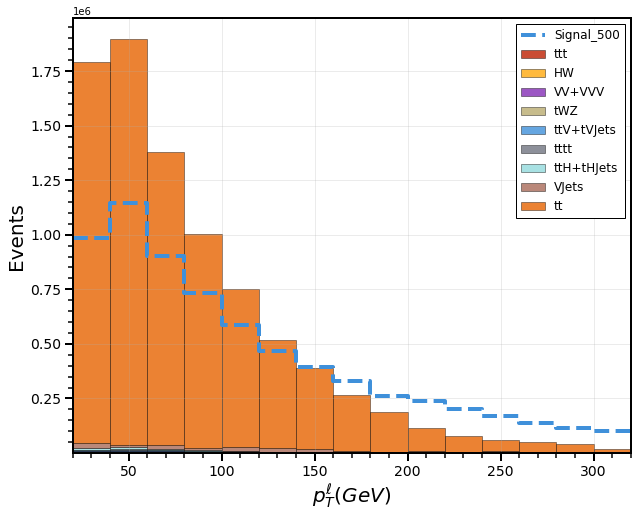

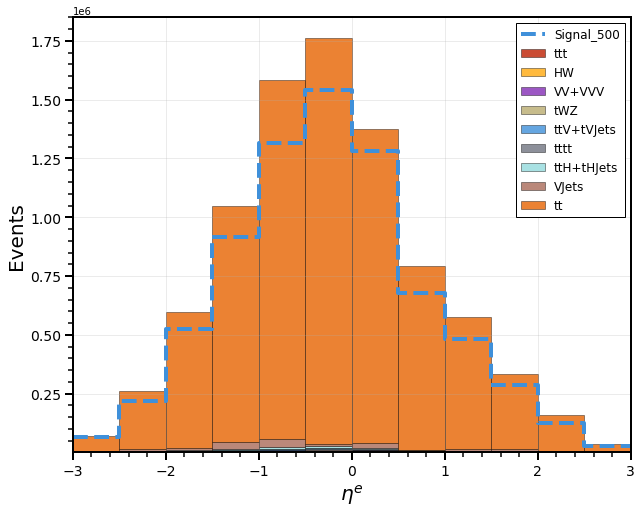

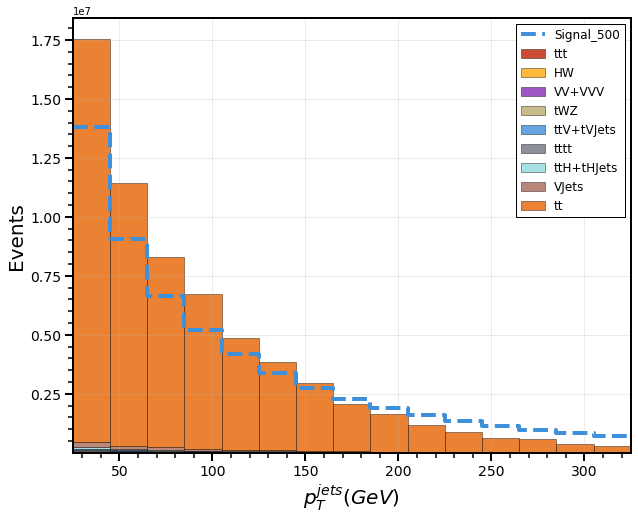

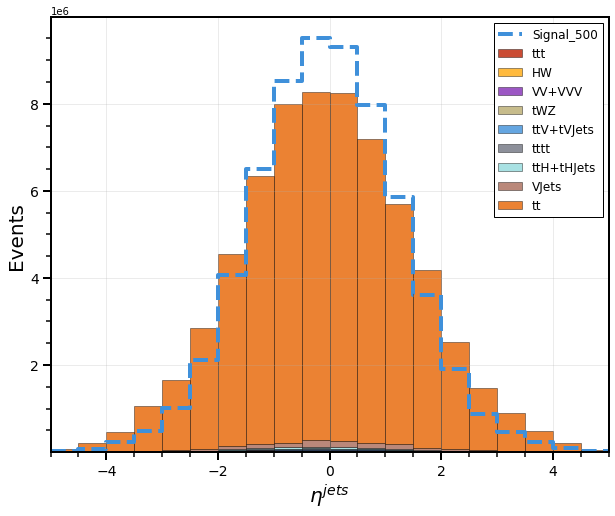

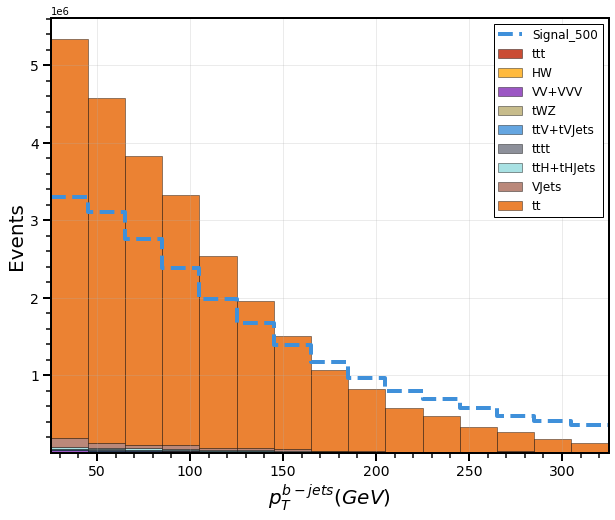

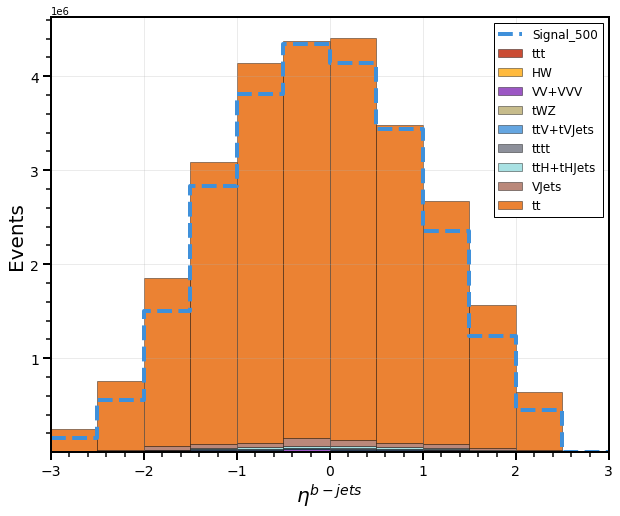

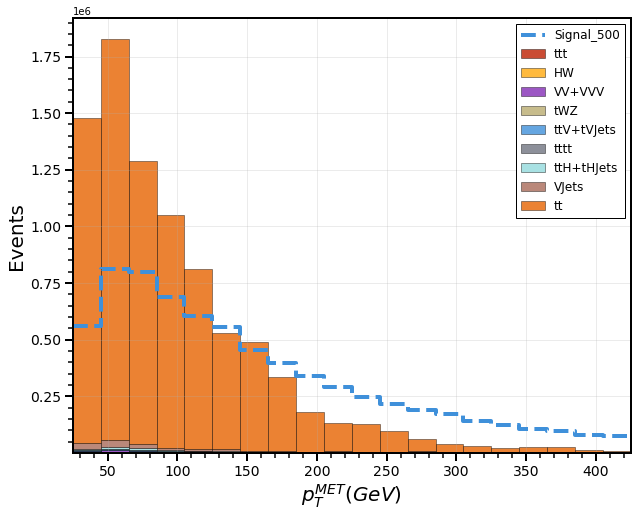

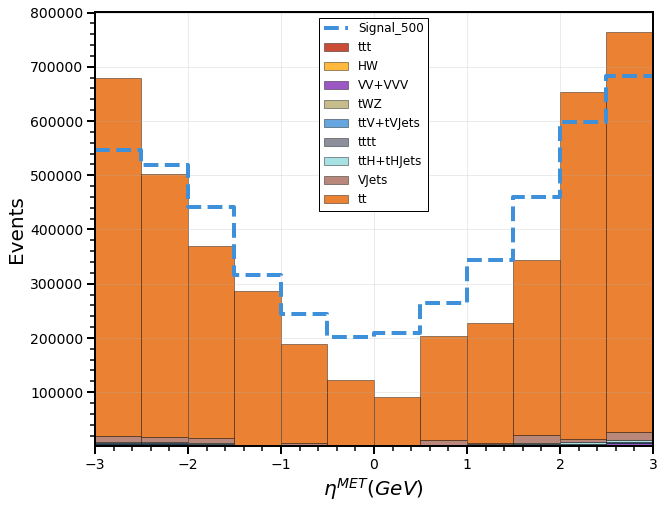

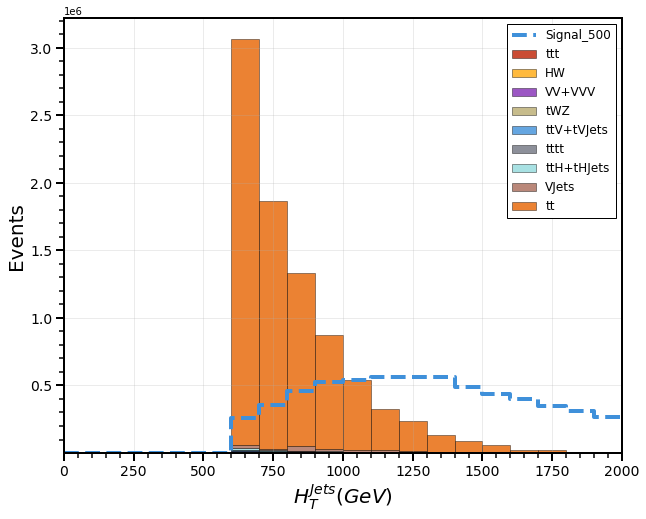

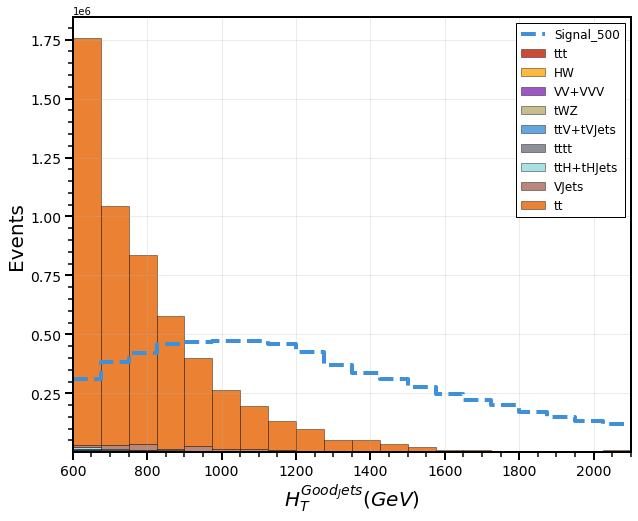

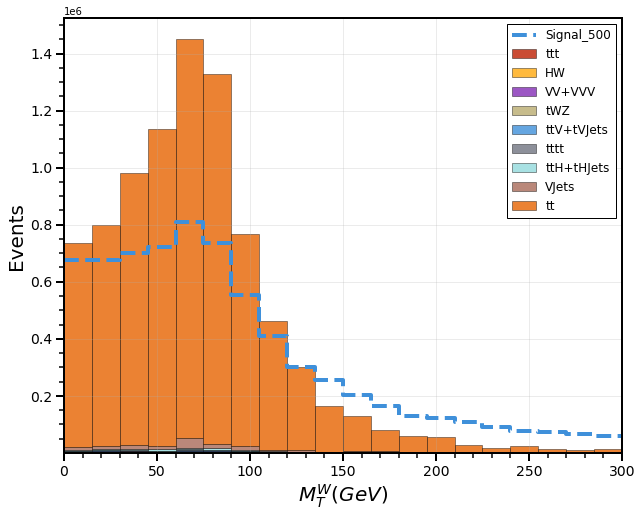

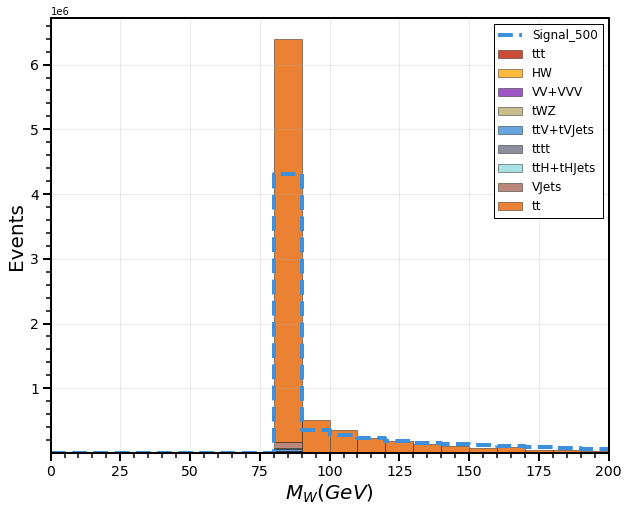

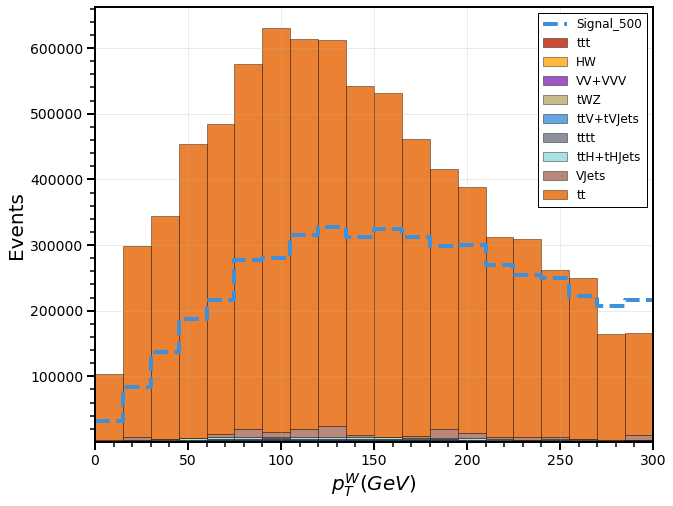

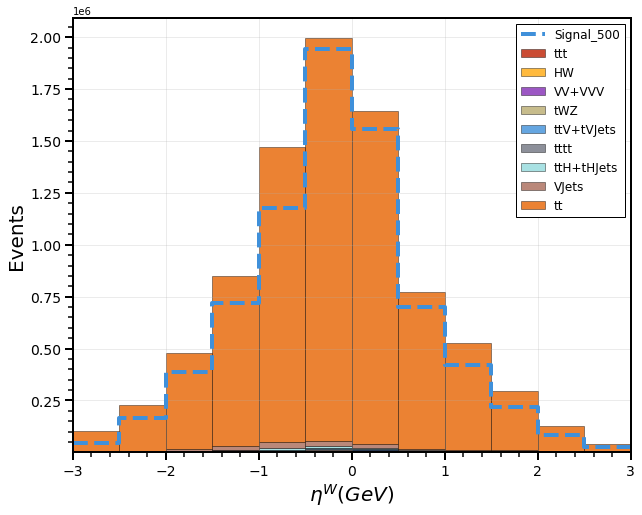

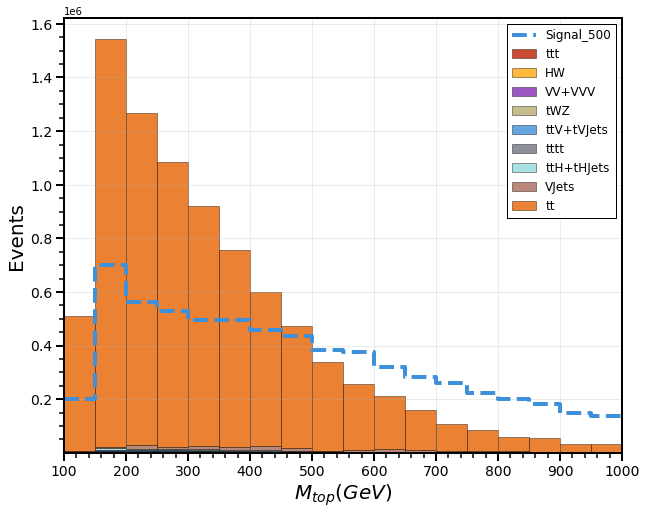

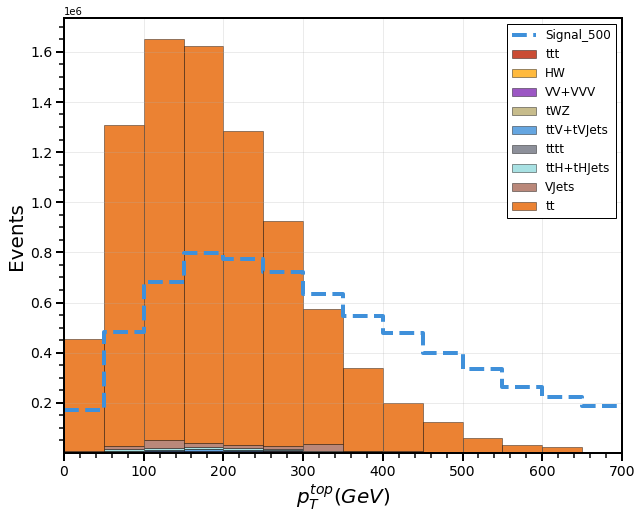

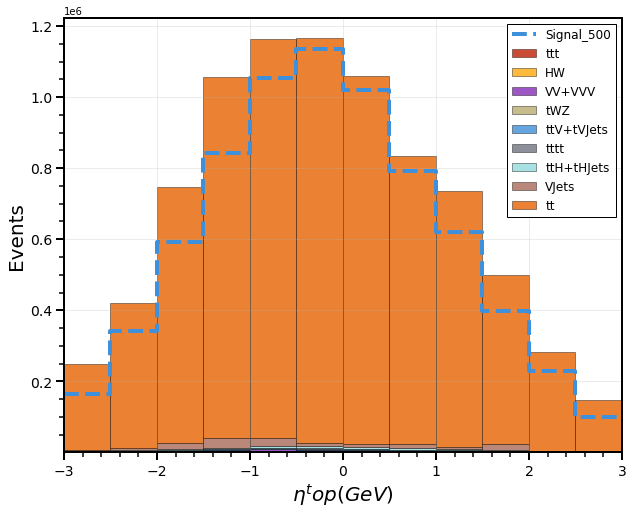

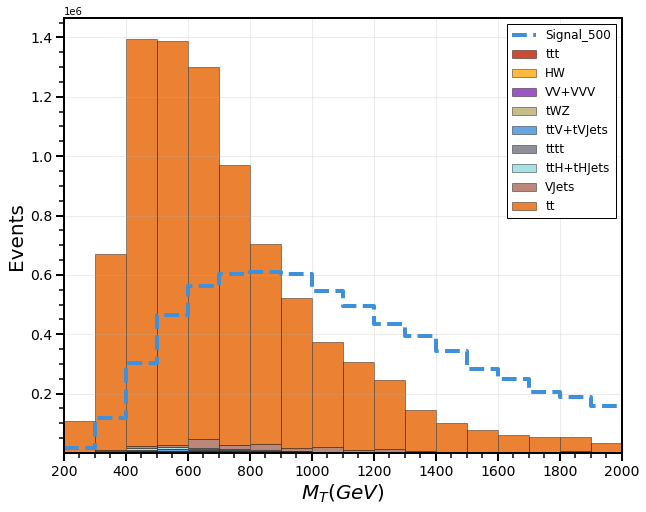

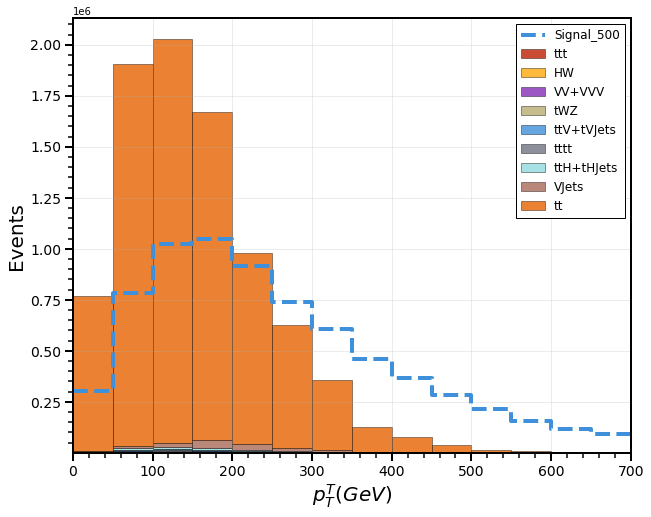

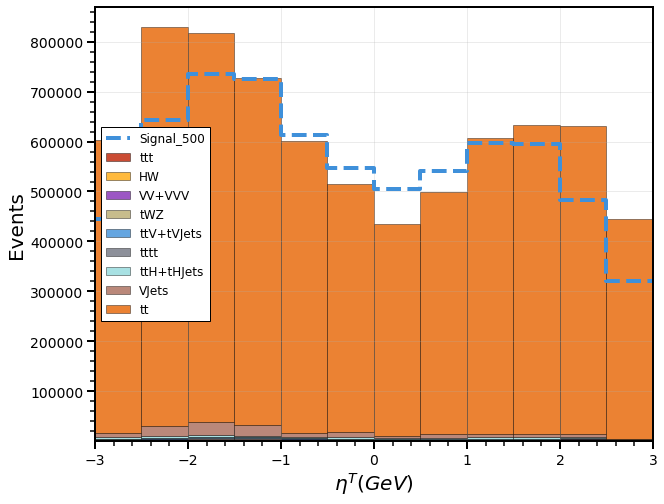

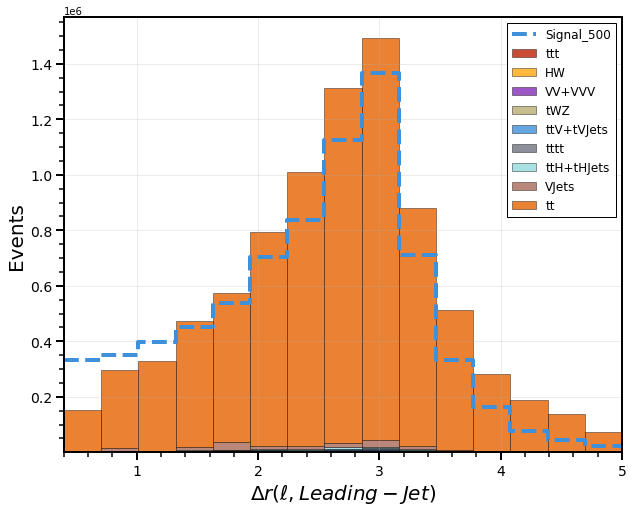

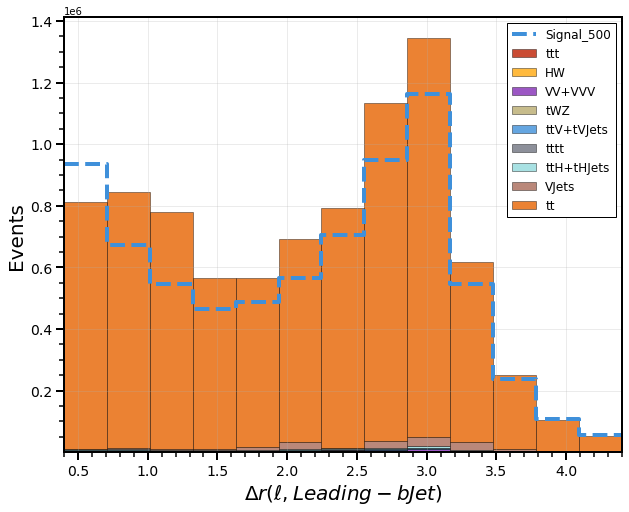

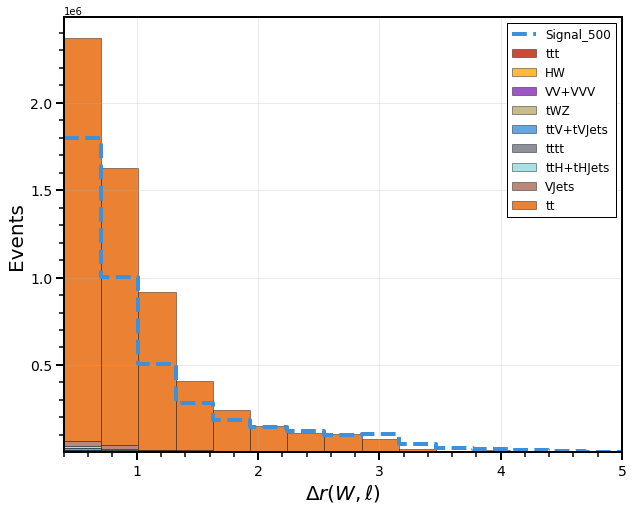

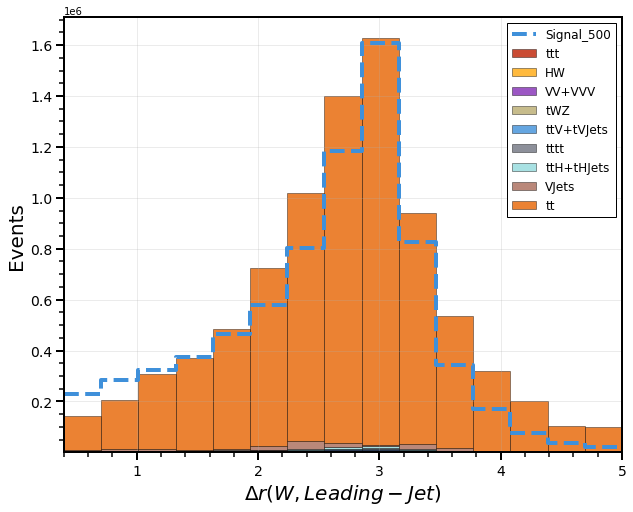

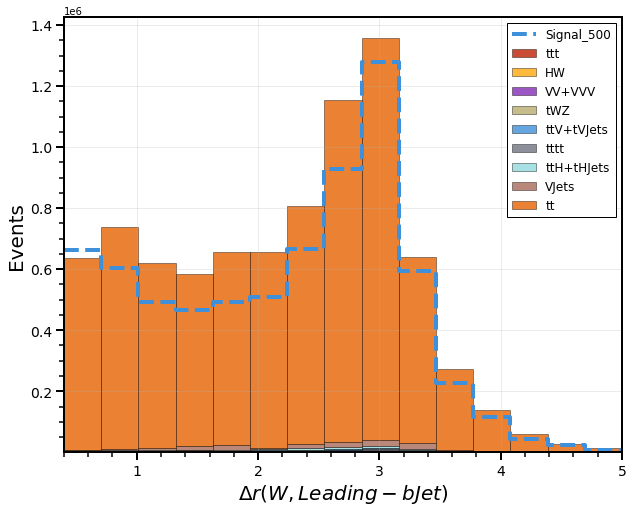

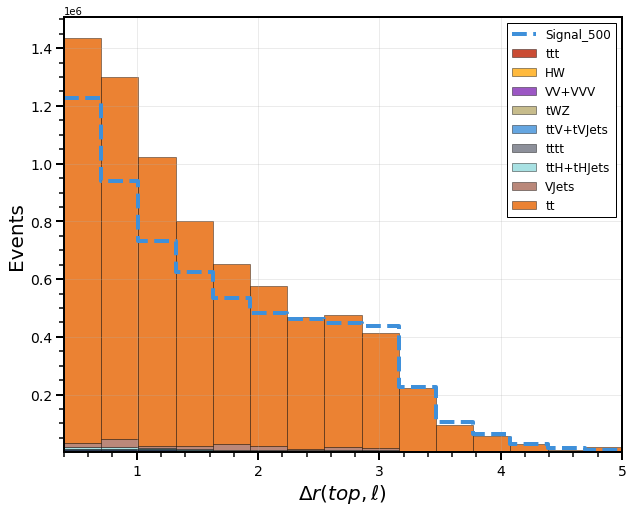

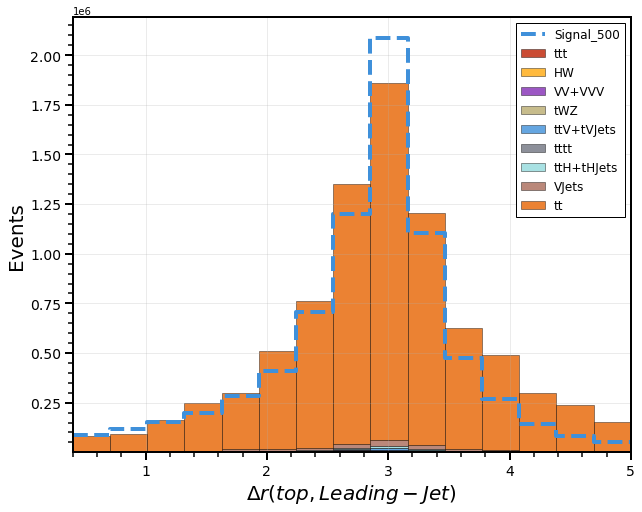

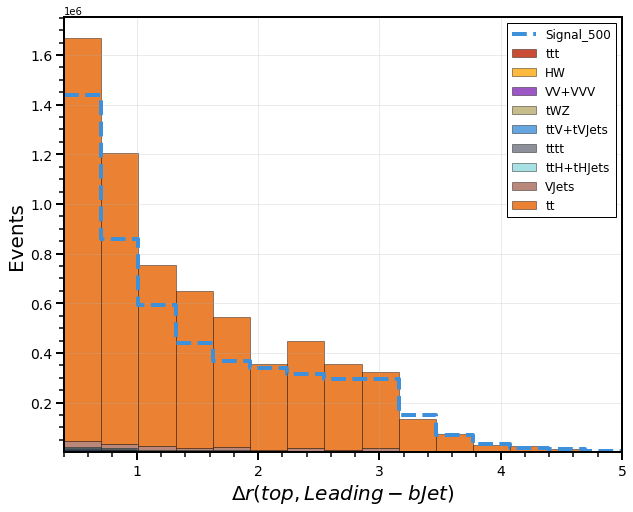

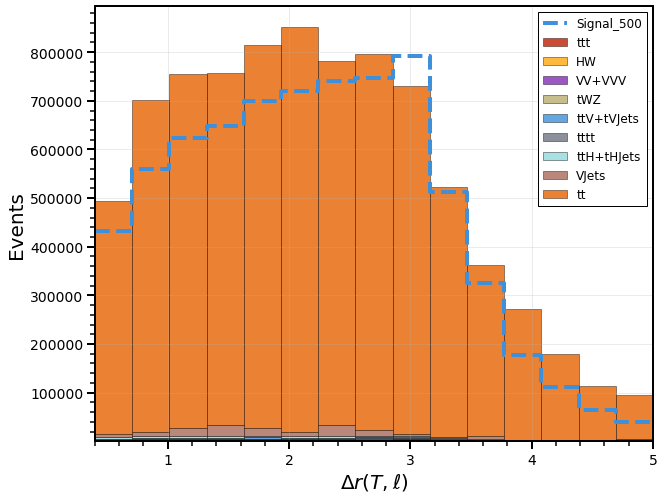

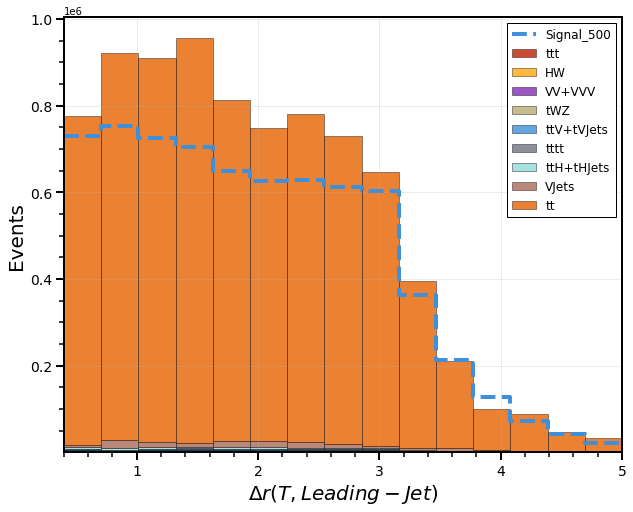

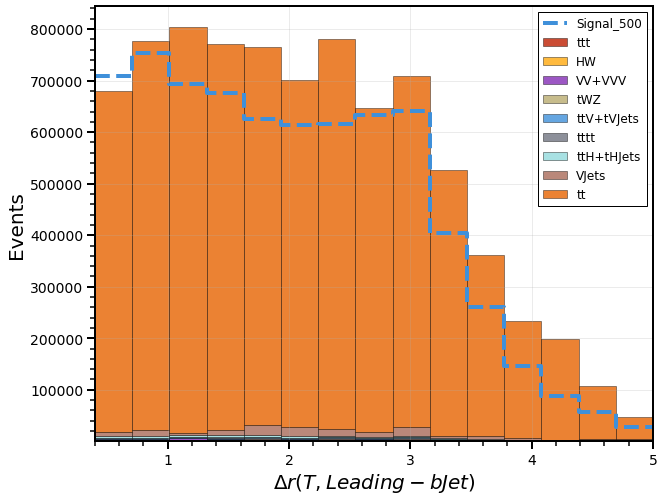

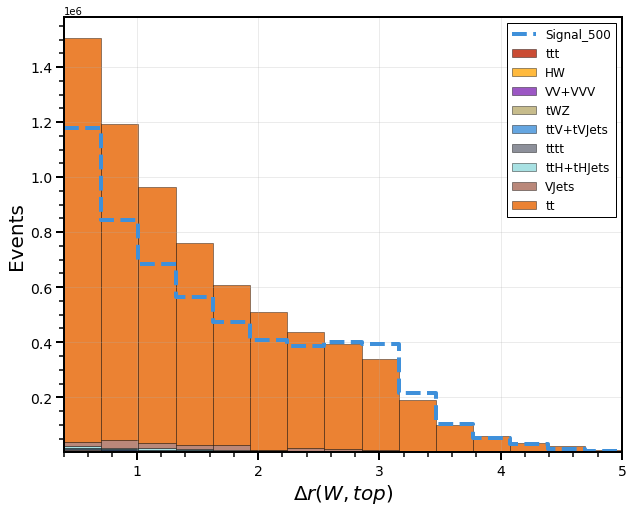

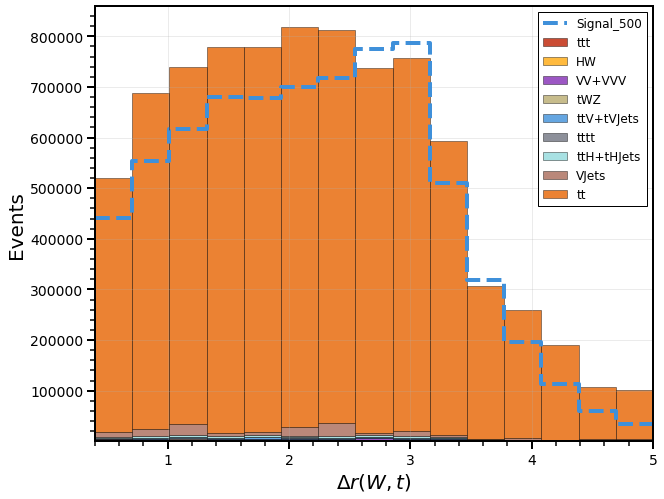

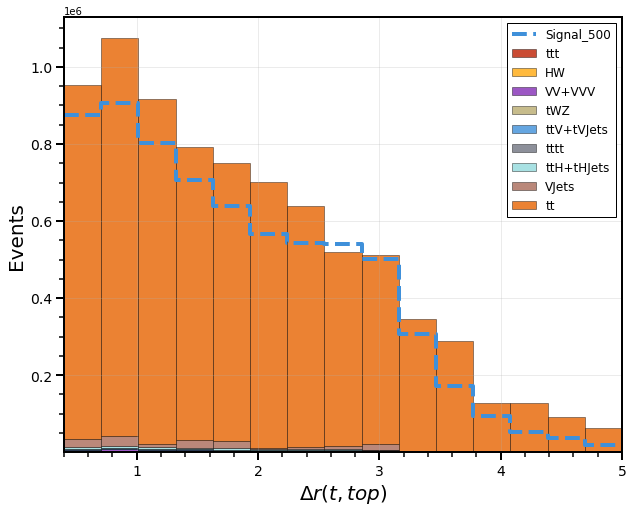

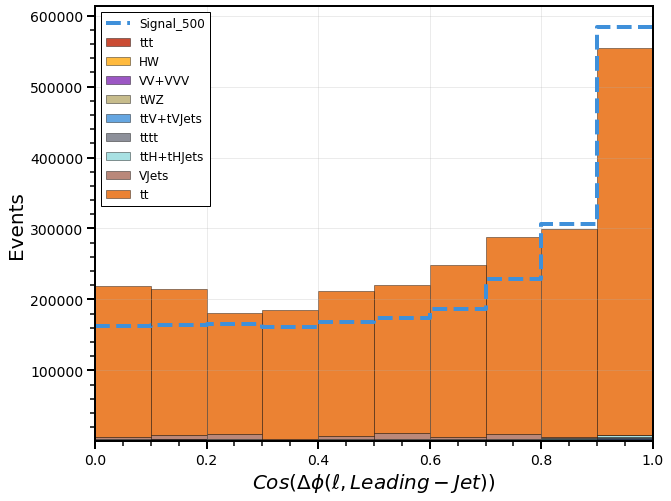

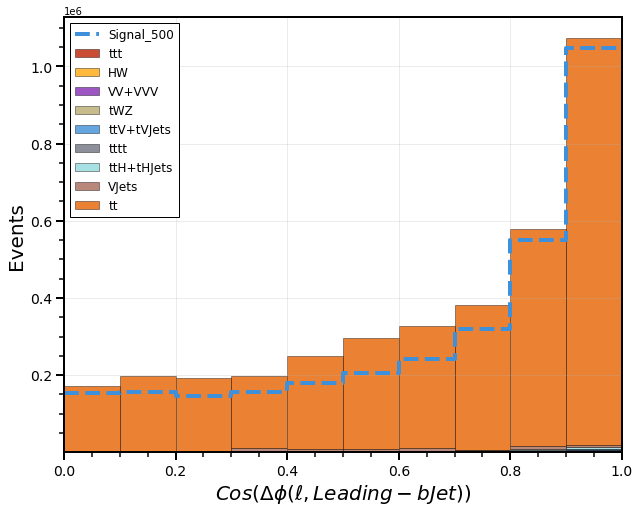

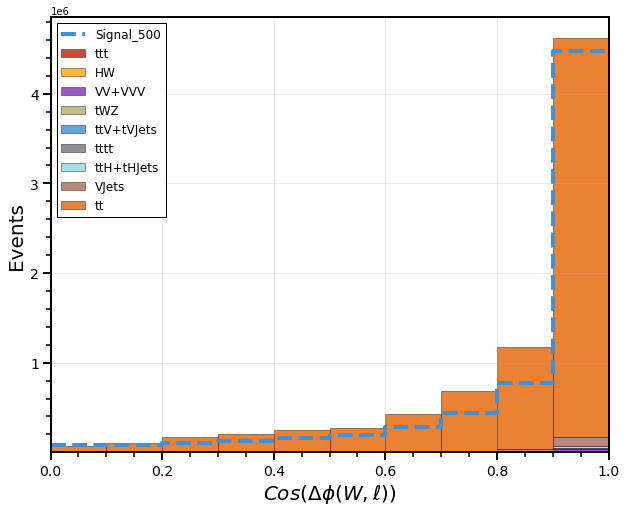

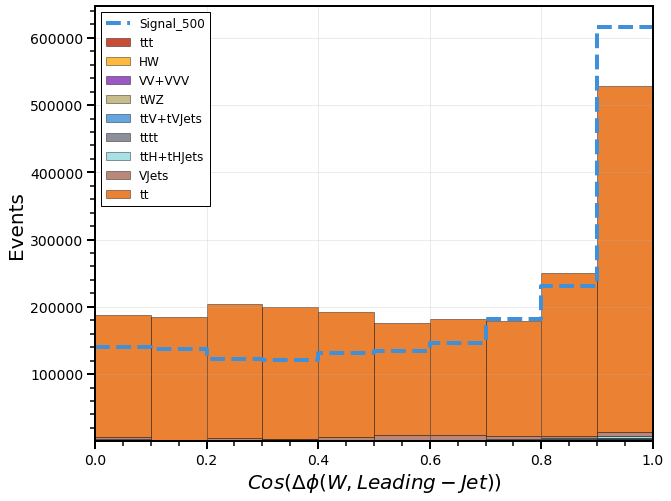

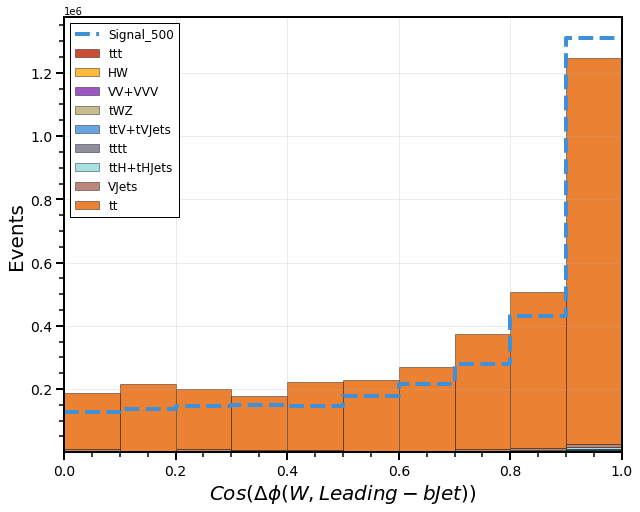

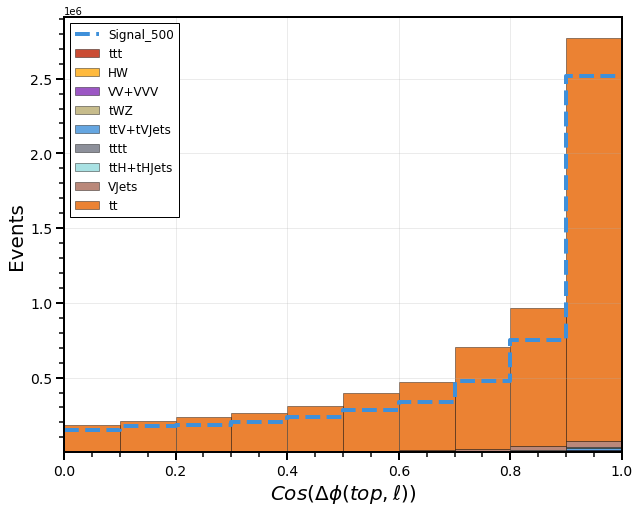

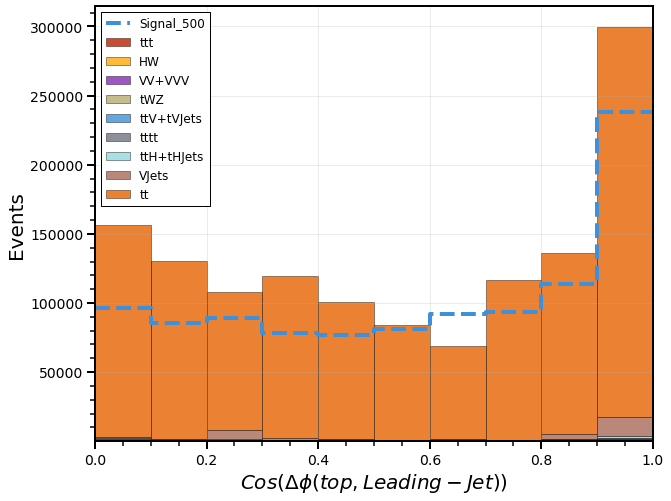

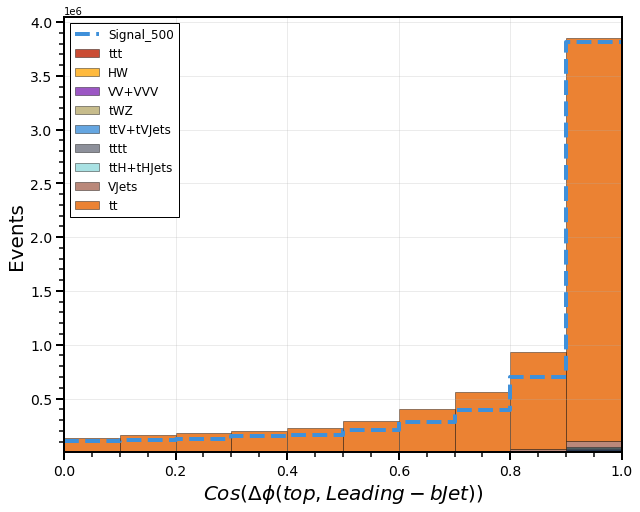

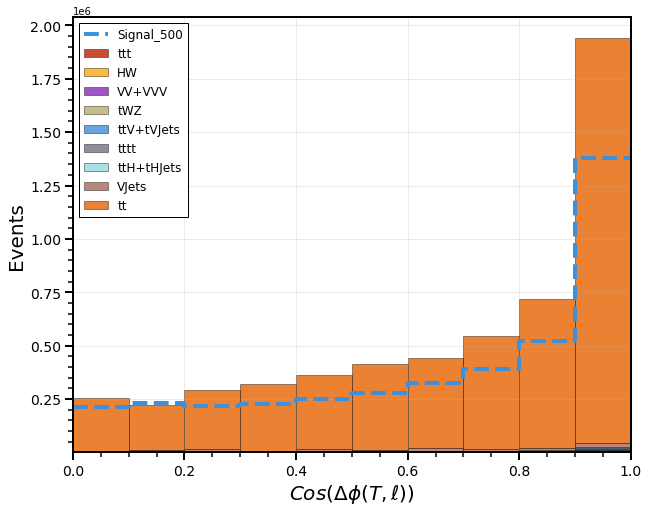

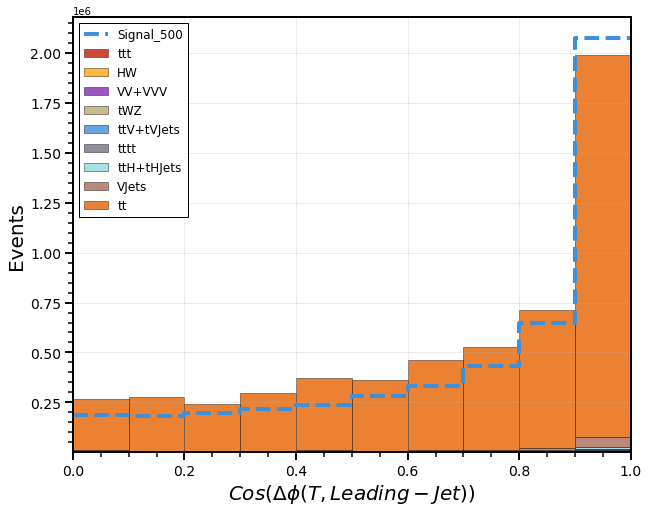

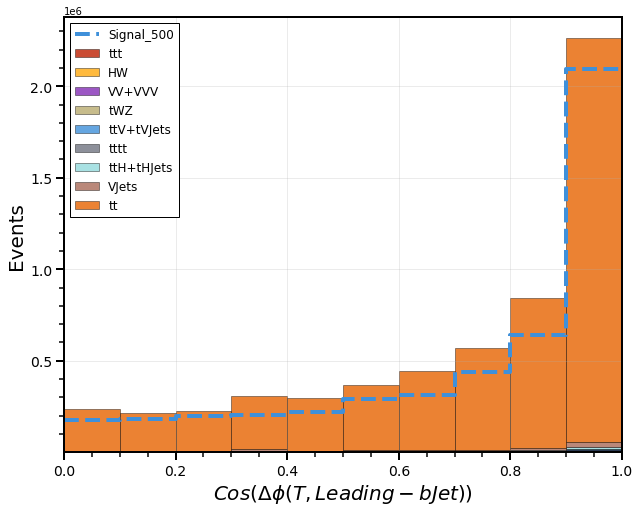

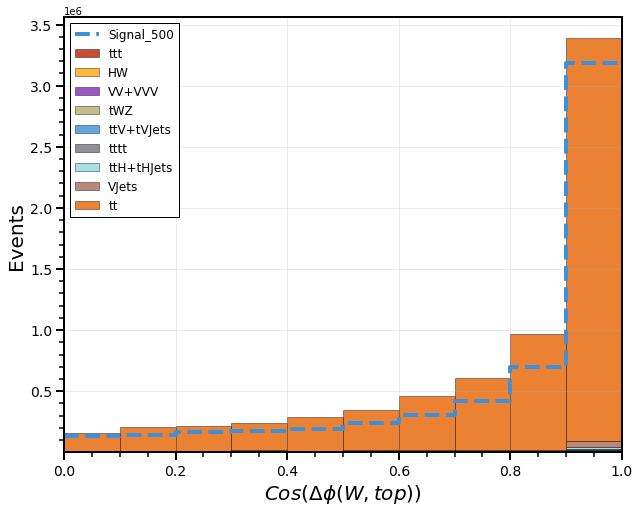

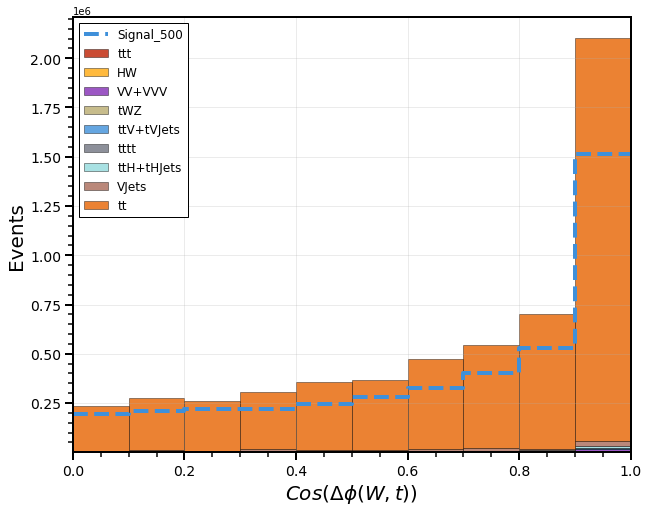

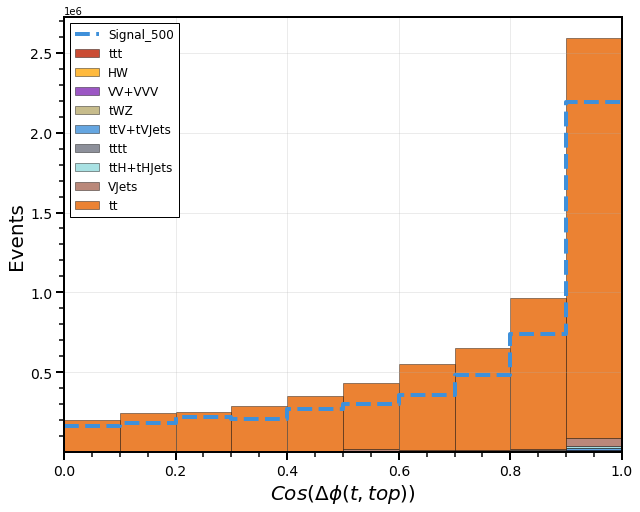

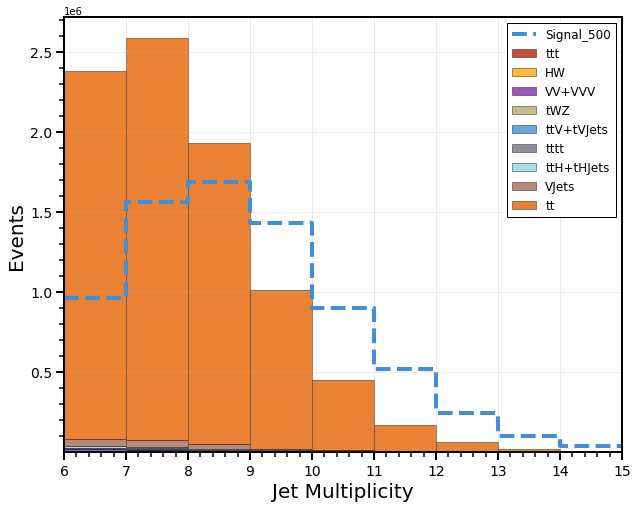

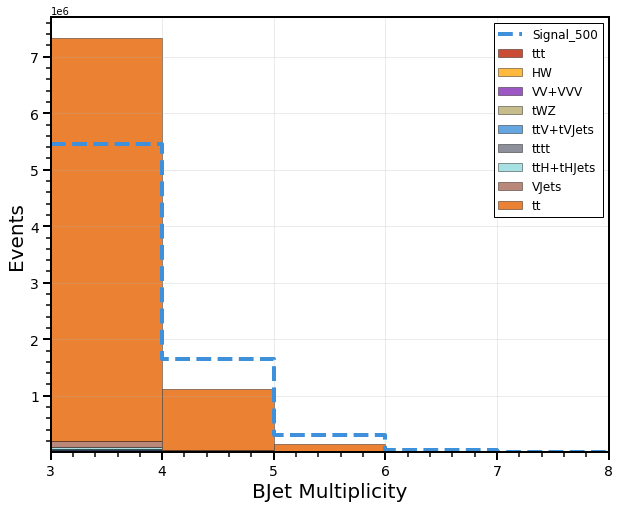

In [9]:
output = load("../output.coffea")

for cat in ["1-lep"]:
    for variable in output["hists"][cat]:
        extractor = ExtractHistData(output)
        hist_data = extractor.extract_hist_info(variable, cat, MC_BCs=mc_backgrounds, signals=signals) # , signals=signals
        if hist_data.has_plot:
            plotter = Plotter(hist_data)
            plotter.plot_histogram()

# for cat in ["1-lep"]:
#     for variable in output["hists"][cat]:
#         extractor = ExtractHistData(output, normalize=True)
#         hist_data = extractor.extract_hist_info(variable, cat, MC_BCs=mc_backgrounds_normalized, signals=signals) # , signals=signals
#         if hist_data.has_plot:
#             plotter = Plotter(hist_data)
#             plotter.plot_histogram(normalized=True)